# Plunge IK controller benchmark analysis

Loads results from `plunge_ik_benchmark.py` and produces:
- Global heatmap (aggregated over all workspace positions)
- Per-position heatmap (one per grid point)
- Per-plunge trajectory plots with RMSE and depth error annotations

**Metrics:**
- **Z RMSE** — RMS error of measured z vs reference cosine
- **Depth error** — error in maximum depth reached vs commanded depth
- **X/Y max drift** — maximum lateral deviation from target x/y

In [11]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

matplotlib.rcParams['figure.dpi'] = 120
RESULTS_DIR = Path('results')
PLOTS_DIR   = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

In [12]:
# ---- Load results ----
result_files = sorted(RESULTS_DIR.glob('plunge_benchmark_*.pkl'))
result_files = [f for f in result_files if '_checkpoint' not in f.name]
print('Available result files:')
for f in result_files:
    print(' ', f.name)

RESULT_FILE = result_files[-1]  # change to pick a specific file
print(f'\nLoading: {RESULT_FILE.name}')
with open(RESULT_FILE, 'rb') as f:
    data = pickle.load(f)

depths    = data['depths']
times     = data['times']
positions = data['positions']
results   = data['results']
print(f'{len(results)} plunges — '
      f'{len(depths)} depths × {len(times)} times × {len(positions)} positions')

Available result files:
  plunge_benchmark_20260522_124938.pkl

Loading: plunge_benchmark_20260522_124938.pkl
225 plunges — 5 depths × 5 times × 9 positions


In [13]:
def reference_z(target_z, depth, probe_time, t_arr):
    s = np.clip(t_arr / probe_time, 0, 1)
    return target_z + depth / 2 * (np.cos(2 * np.pi * s) - 1)

In [14]:
# ---- Compute metrics for every plunge ----
def compute_metrics(r):
    target_xyz = r['target_xyz']
    depth      = r['depth']
    probe_time = r['probe_time']
    ts         = r['ts']                 # (N_meas,)
    meas_pos   = r['measured_positions'] # (N_meas, 3)

    metrics = {k: np.nan for k in ['z_rmse', 'depth_error', 'xy_max_drift',
                                    'x_max_drift', 'y_max_drift', 'z_max_err']}

    if len(ts) == 0 or len(meas_pos) == 0:
        return metrics

    ref_z_meas = reference_z(target_xyz[2], depth, probe_time, ts)

    # Z RMSE: reference vs measured
    z_err = meas_pos[:, 2] - ref_z_meas
    metrics['z_rmse']   = float(np.sqrt(np.mean(z_err**2))) * 1e3   # mm
    metrics['z_max_err']= float(np.max(np.abs(z_err))) * 1e3

    # Depth error: |actual min z  −  expected min z|
    # Expected min z for cosine: target_z − depth
    expected_min_z = target_xyz[2] - depth
    actual_min_z   = float(np.min(meas_pos[:, 2]))
    metrics['depth_error'] = abs(actual_min_z - expected_min_z) * 1e3  # mm

    # X/Y max drift from target
    metrics['x_max_drift']  = float(np.max(np.abs(meas_pos[:, 0] - target_xyz[0]))) * 1e3
    metrics['y_max_drift']  = float(np.max(np.abs(meas_pos[:, 1] - target_xyz[1]))) * 1e3
    metrics['xy_max_drift'] = float(np.max(
        np.sqrt((meas_pos[:, 0] - target_xyz[0])**2 +
                (meas_pos[:, 1] - target_xyz[1])**2)
    )) * 1e3

    return metrics

for r in results:
    r['metrics'] = compute_metrics(r)
print('Metrics computed.')

Metrics computed.


In [15]:
# ---- Aggregate metrics: global + per position ----
METRIC_KEYS   = ['z_rmse', 'depth_error', 'xy_max_drift']
METRIC_LABELS = ['Z RMSE (ref vs measured) [mm]',
                 'Depth error [mm]',
                 'X/Y max drift [mm]']

def make_grids(result_subset):
    """Build mean/std grids (n_depths × n_times) from a subset of results."""
    mean_g = {k: np.full((len(depths), len(times)), np.nan) for k in METRIC_KEYS}
    std_g  = {k: np.full((len(depths), len(times)), np.nan) for k in METRIC_KEYS}
    for di in range(len(depths)):
        for ti in range(len(times)):
            cell = [r for r in result_subset
                    if r['depth_idx'] == di and r['time_idx'] == ti]
            for k in METRIC_KEYS:
                vals = [r['metrics'][k] for r in cell
                        if not np.isnan(r['metrics'].get(k, np.nan))]
                if vals:
                    mean_g[k][di, ti] = np.mean(vals)
                    std_g[k][di, ti]  = np.std(vals)
    return mean_g, std_g

global_mean, global_std = make_grids(results)

per_pos_grids = []
for pos_idx in range(len(positions)):
    subset = [r for r in results if r['pos_idx'] == pos_idx]
    per_pos_grids.append(make_grids(subset))

print('Aggregation done.')

Aggregation done.


In [16]:
# ---- Heatmap helper ----
def draw_heatmap(fig, axes, mean_grids, std_grids, title, vmax_override=None):
    """Fill a row of axes with one heatmap per metric."""
    is_2d = len(depths) > 1 and len(times) > 1
    fig.suptitle(title, fontsize=10)

    # imshow extent covers outer edges, so cell centers are offset by half a cell
    if is_2d:
        dx = (times[-1] - times[0]) / len(times)
        dy = (depths[-1] - depths[0]) * 1e3 / len(depths)
        x_centers = times[0]        + dx * (np.arange(len(times))  + 0.5)
        y_centers = depths[0] * 1e3 + dy * (np.arange(len(depths)) + 0.5)

    for ax, key, label in zip(axes, METRIC_KEYS, METRIC_LABELS):
        grid = mean_grids[key]
        vmax = vmax_override[key] if vmax_override else None

        if is_2d:
            im = ax.imshow(grid, aspect='auto', origin='lower',
                           extent=[times[0], times[-1], depths[0]*1e3, depths[-1]*1e3],
                           cmap='YlOrRd', vmin=0, vmax=vmax)
            fig.colorbar(im, ax=ax, label='mm')
            finite = grid[~np.isnan(grid)]
            dark = vmax if vmax else (finite.max() if len(finite) else 1)
            for di in range(len(depths)):
                for ti in range(len(times)):
                    m = mean_grids[key][di, ti]
                    s = std_grids[key][di, ti]
                    if not np.isnan(m):
                        color = 'white' if m > dark * 0.7 else 'black'
                        txt = f'{m:.2f}' + (f'\n±{s:.2f}' if not np.isnan(s) else '')
                        ax.text(x_centers[ti], y_centers[di], txt,
                                ha='center', va='center', fontsize=7, color=color)
            ax.set_xlabel('Probe time (s)')
            ax.set_ylabel('Depth (mm)')
        else:
            combo_labels = [f'd={d*1e3:.0f}mm\nt={t:.2f}s'
                            for d in depths for t in times]
            means = [mean_grids[key][di, ti]
                     for di in range(len(depths)) for ti in range(len(times))]
            stds  = [std_grids[key][di, ti]
                     for di in range(len(depths)) for ti in range(len(times))]
            x = np.arange(len(combo_labels))
            ax.bar(x, means, yerr=stds, capsize=4, color='steelblue', alpha=0.8)
            ax.set_xticks(x)
            ax.set_xticklabels(combo_labels, fontsize=8)
            ax.set_ylabel('mm')
            for xi, (m, s) in enumerate(zip(means, stds)):
                if not np.isnan(m):
                    ax.text(xi, m + (s if not np.isnan(s) else 0) + 0.02,
                            f'{m:.2f}', ha='center', va='bottom', fontsize=8)

        ax.set_title(label)
        ax.grid(axis='y', linewidth=0.4)

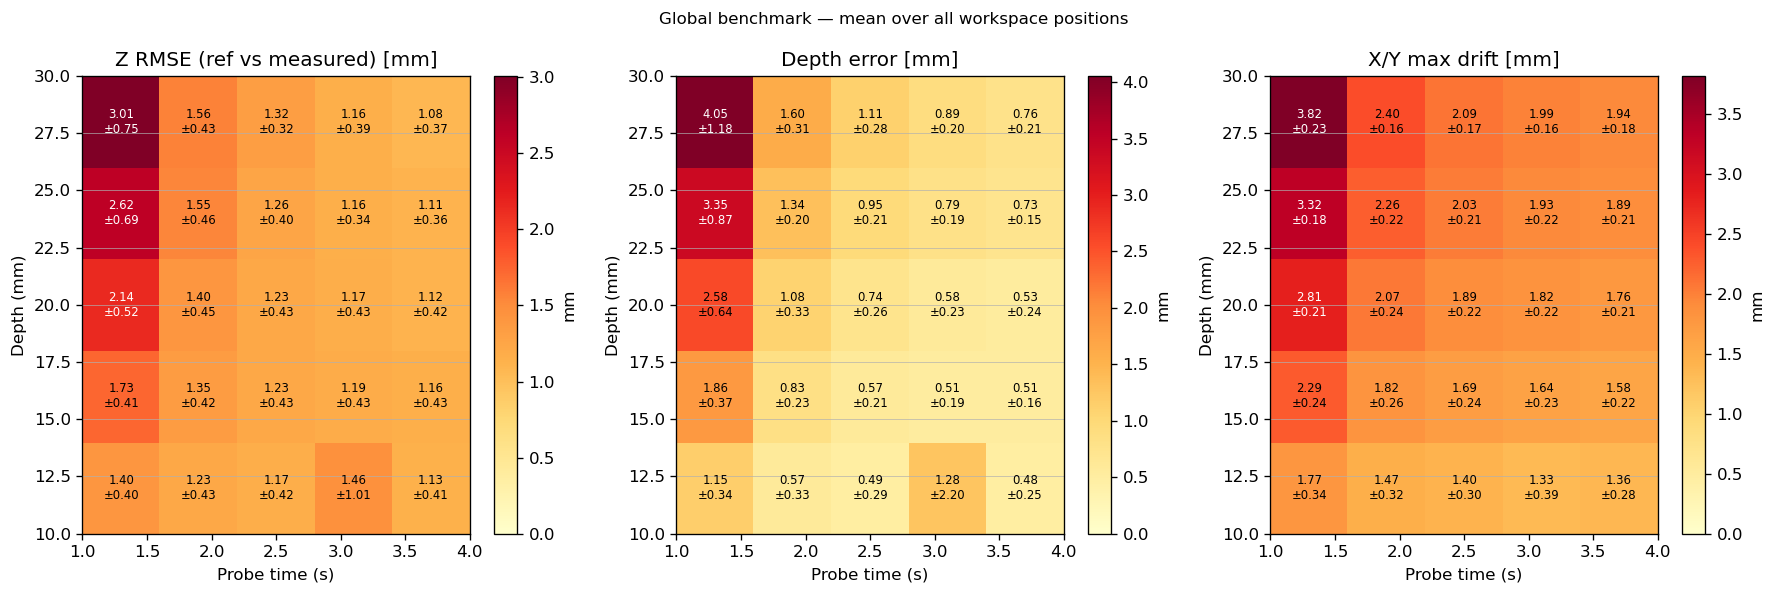

Saved: heatmap_global_plunge_benchmark_20260522_124938.png


In [17]:
# ---- Global heatmap (mean over all positions) ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
draw_heatmap(fig, axes, global_mean, global_std,
             title='Global benchmark — mean over all workspace positions')
plt.tight_layout()
out = PLOTS_DIR / f'heatmap_global_{RESULT_FILE.stem}.png'
plt.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.name}')

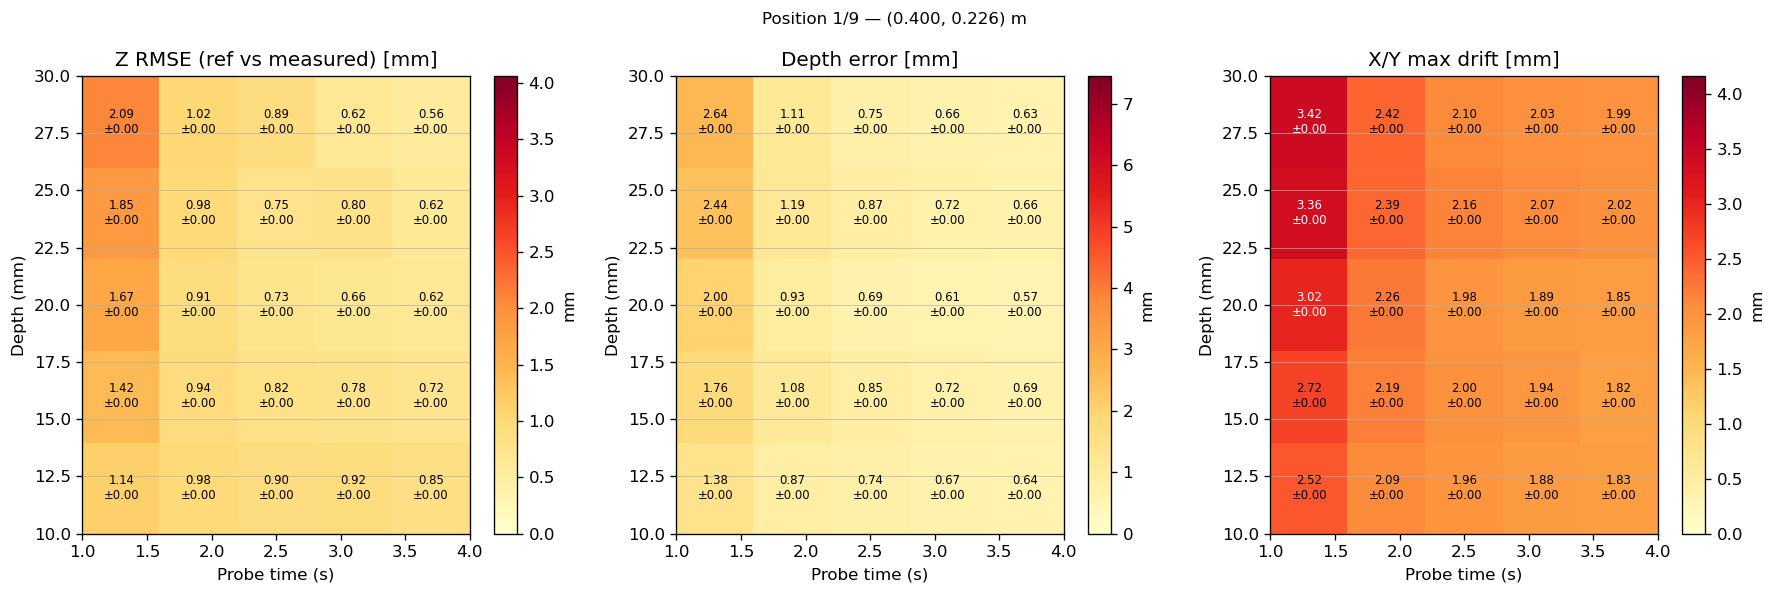

Saved: heatmap_pos00_plunge_benchmark_20260522_124938.png


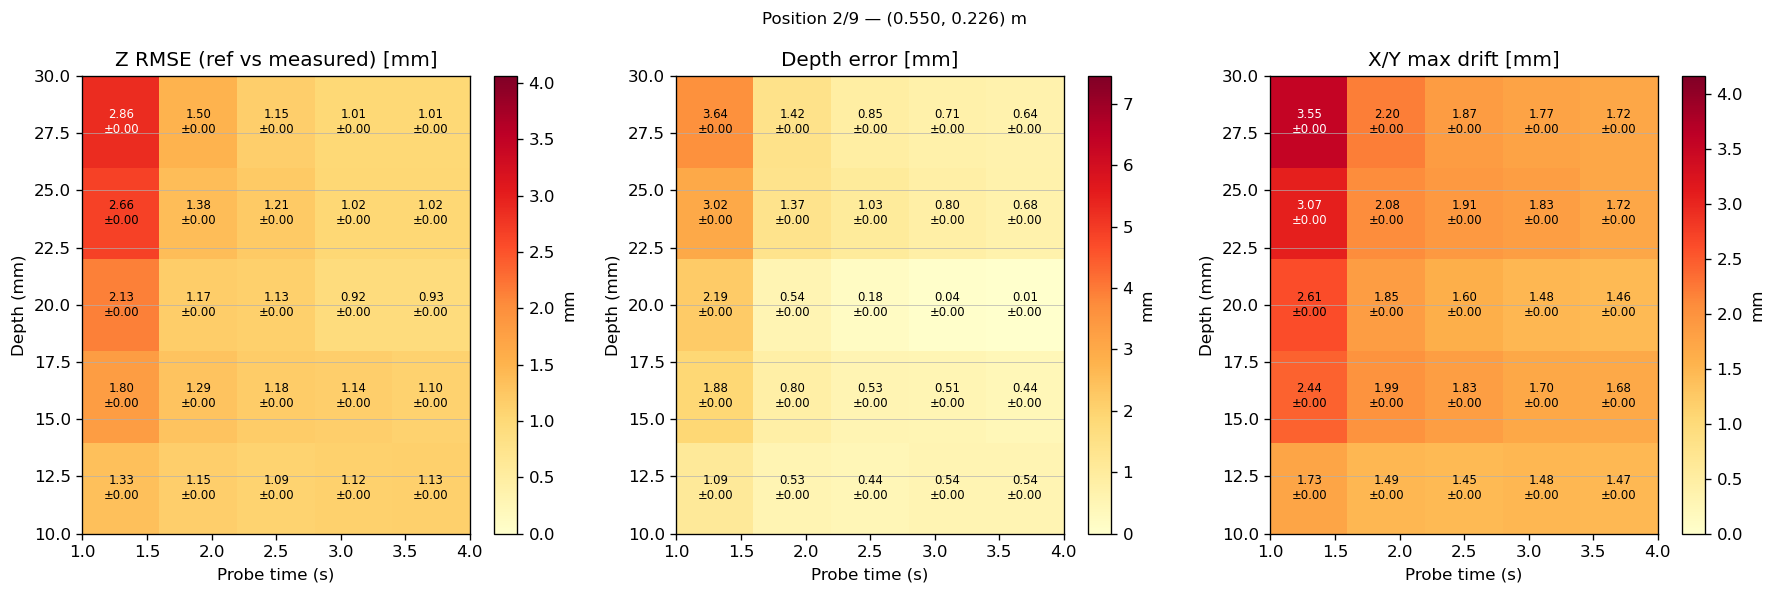

Saved: heatmap_pos01_plunge_benchmark_20260522_124938.png


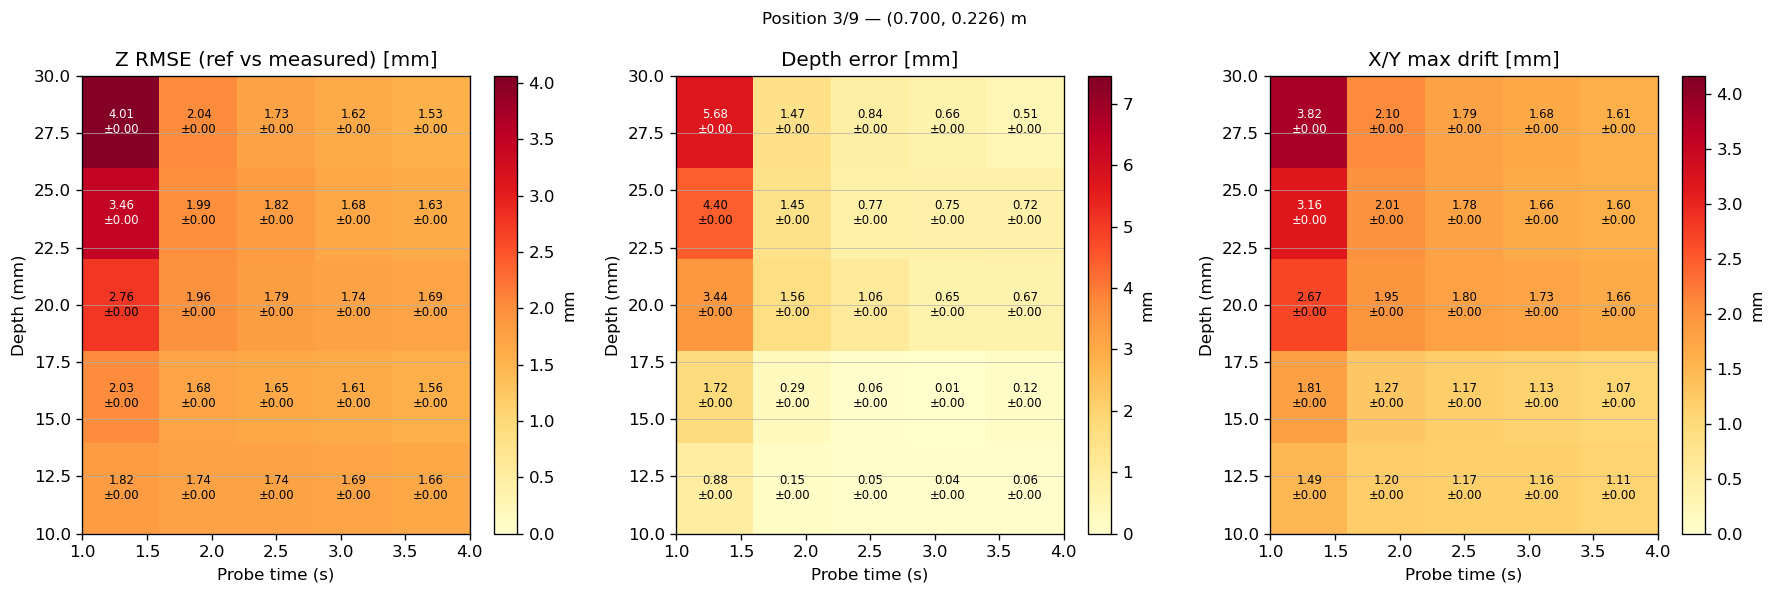

Saved: heatmap_pos02_plunge_benchmark_20260522_124938.png


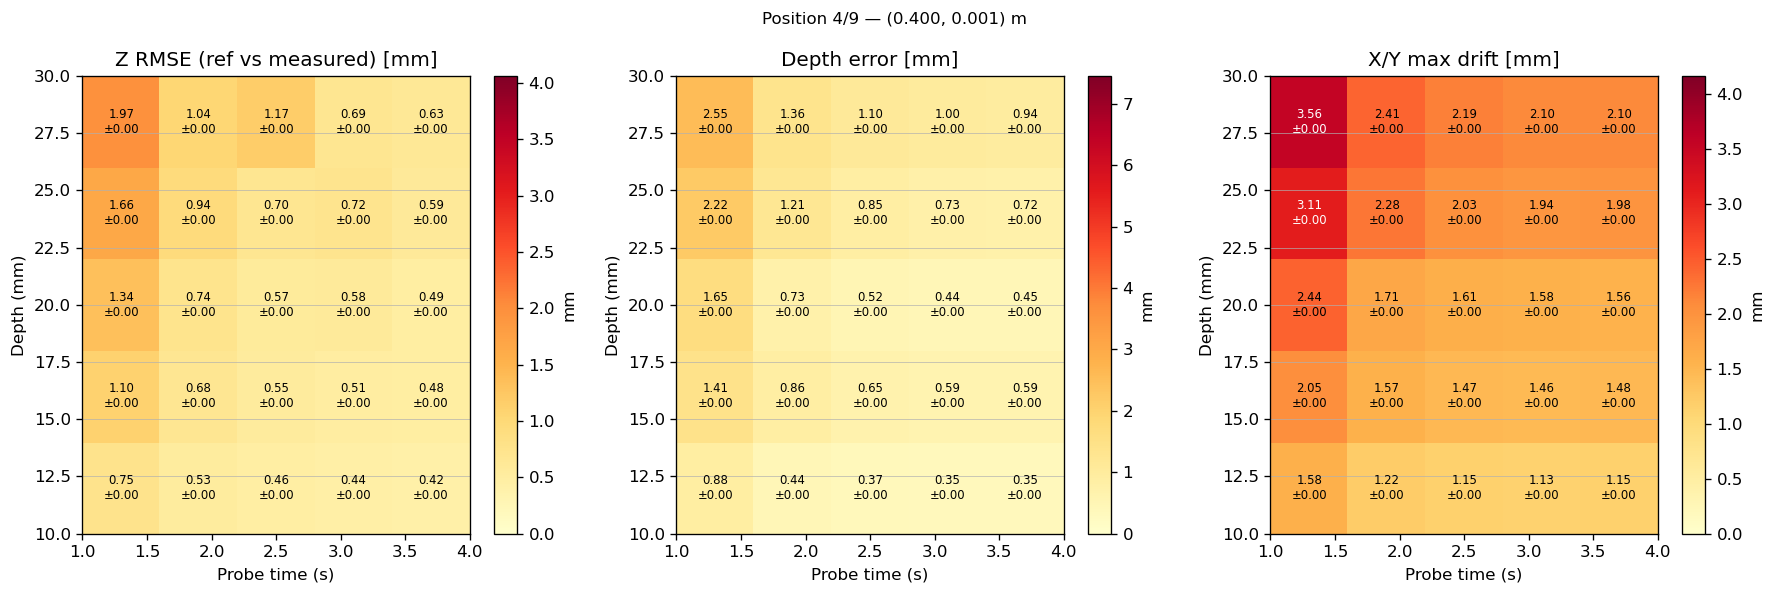

Saved: heatmap_pos03_plunge_benchmark_20260522_124938.png


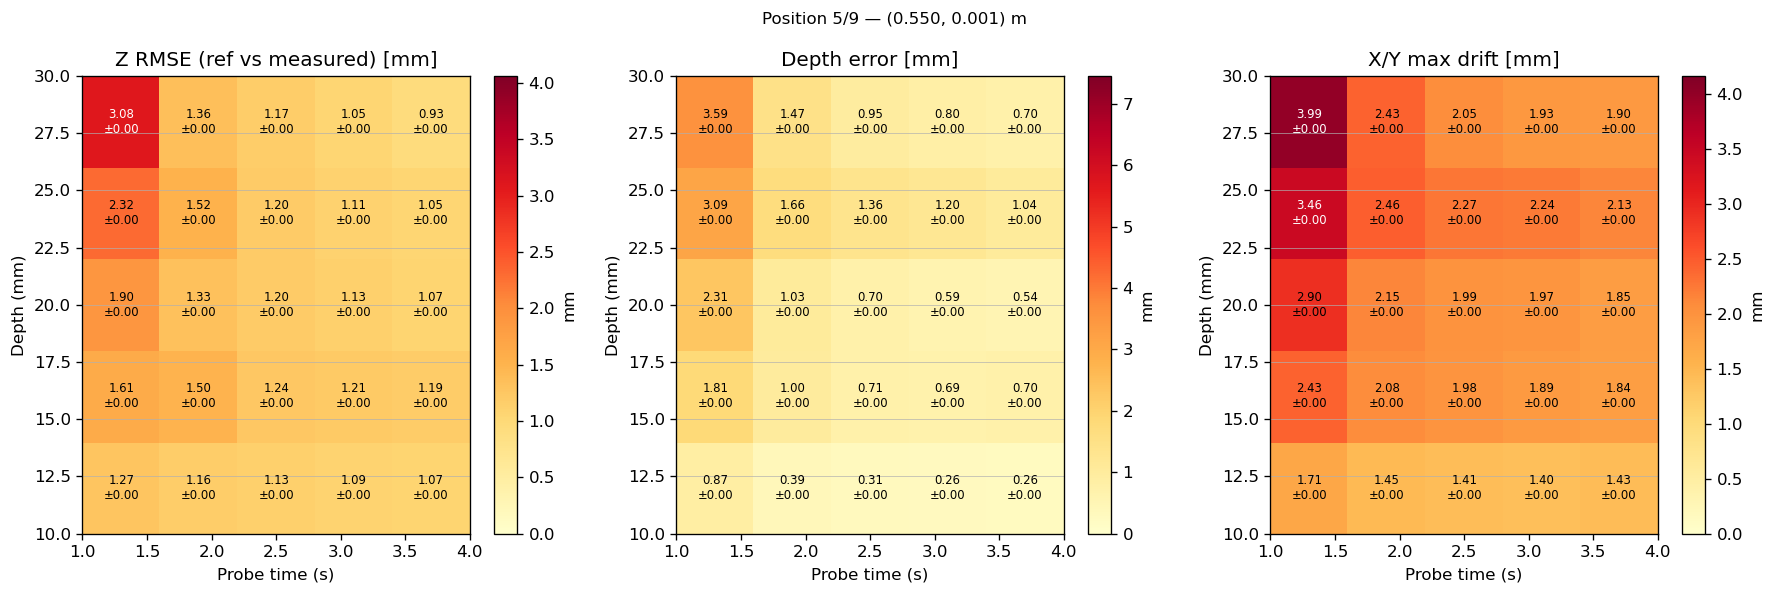

Saved: heatmap_pos04_plunge_benchmark_20260522_124938.png


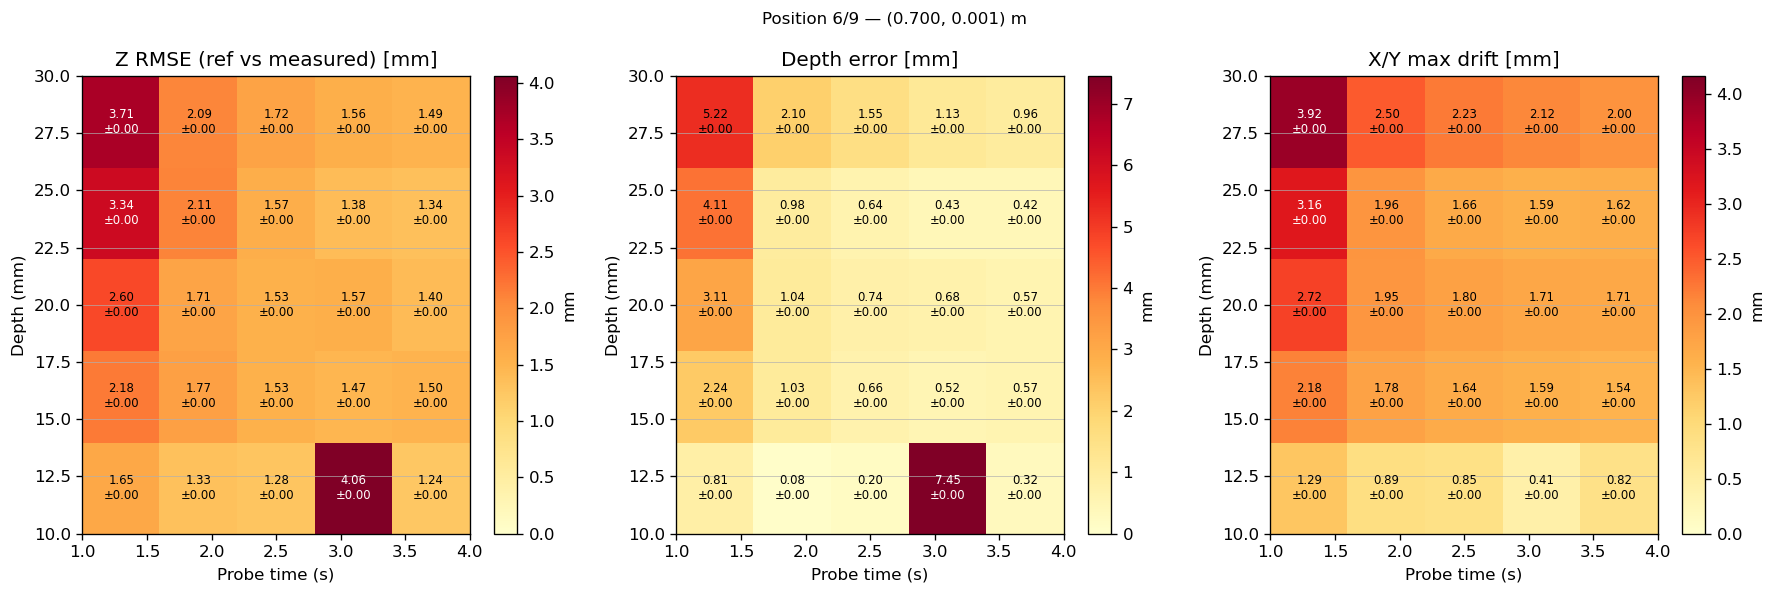

Saved: heatmap_pos05_plunge_benchmark_20260522_124938.png


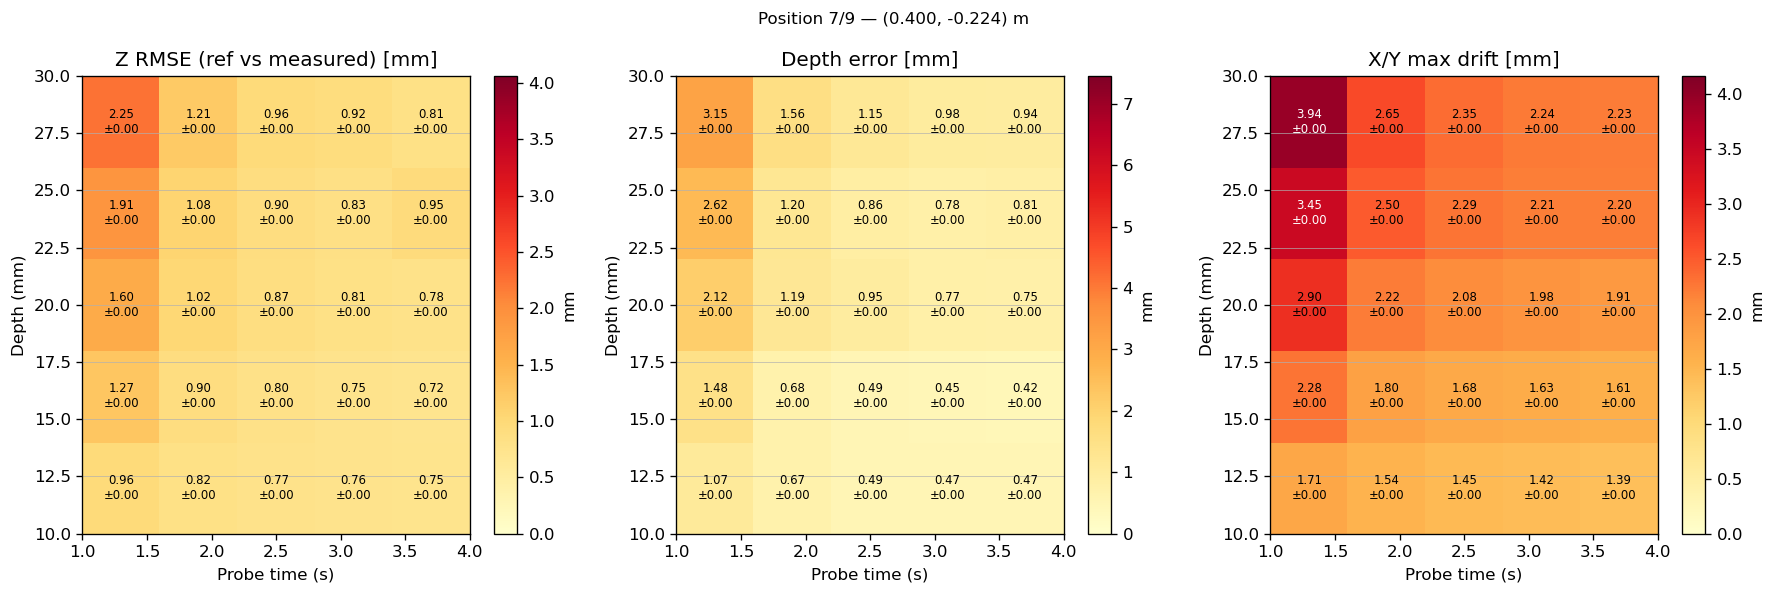

Saved: heatmap_pos06_plunge_benchmark_20260522_124938.png


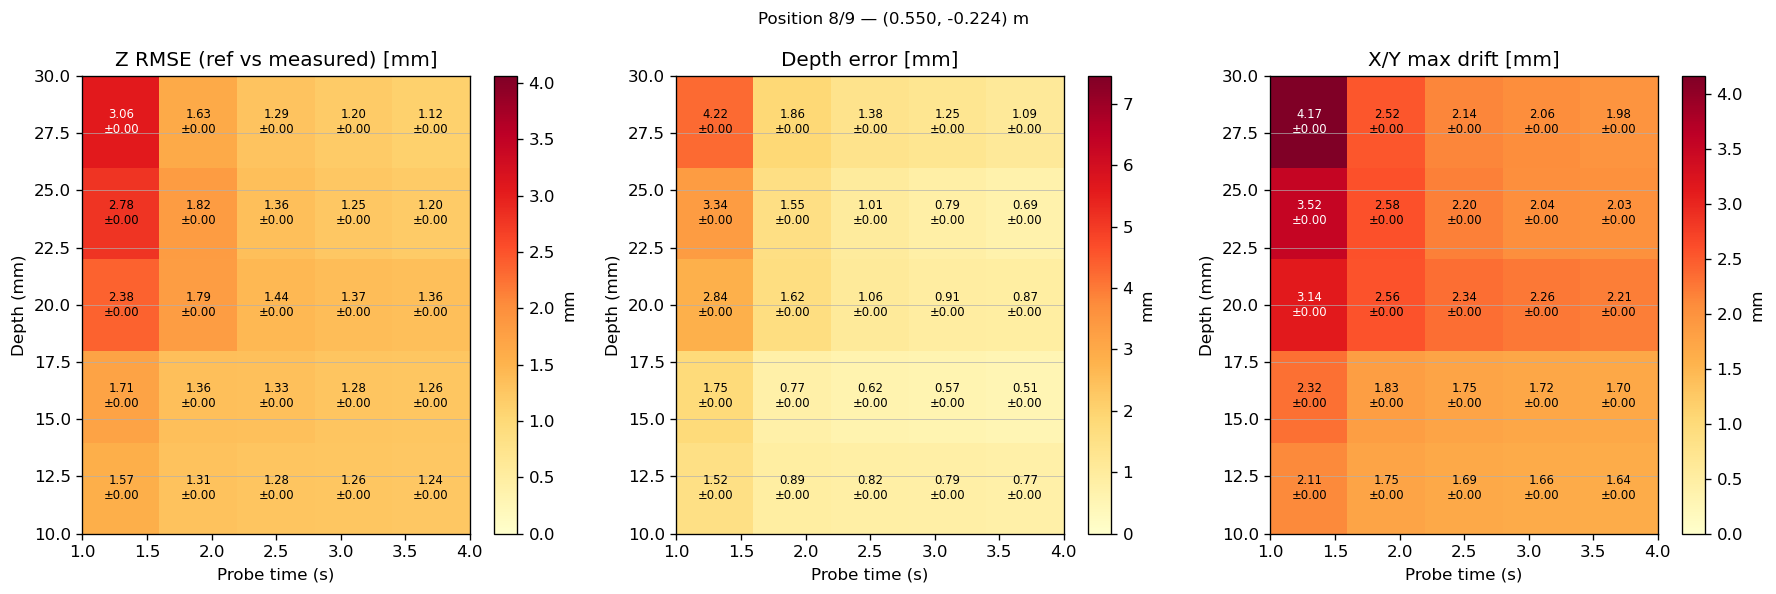

Saved: heatmap_pos07_plunge_benchmark_20260522_124938.png


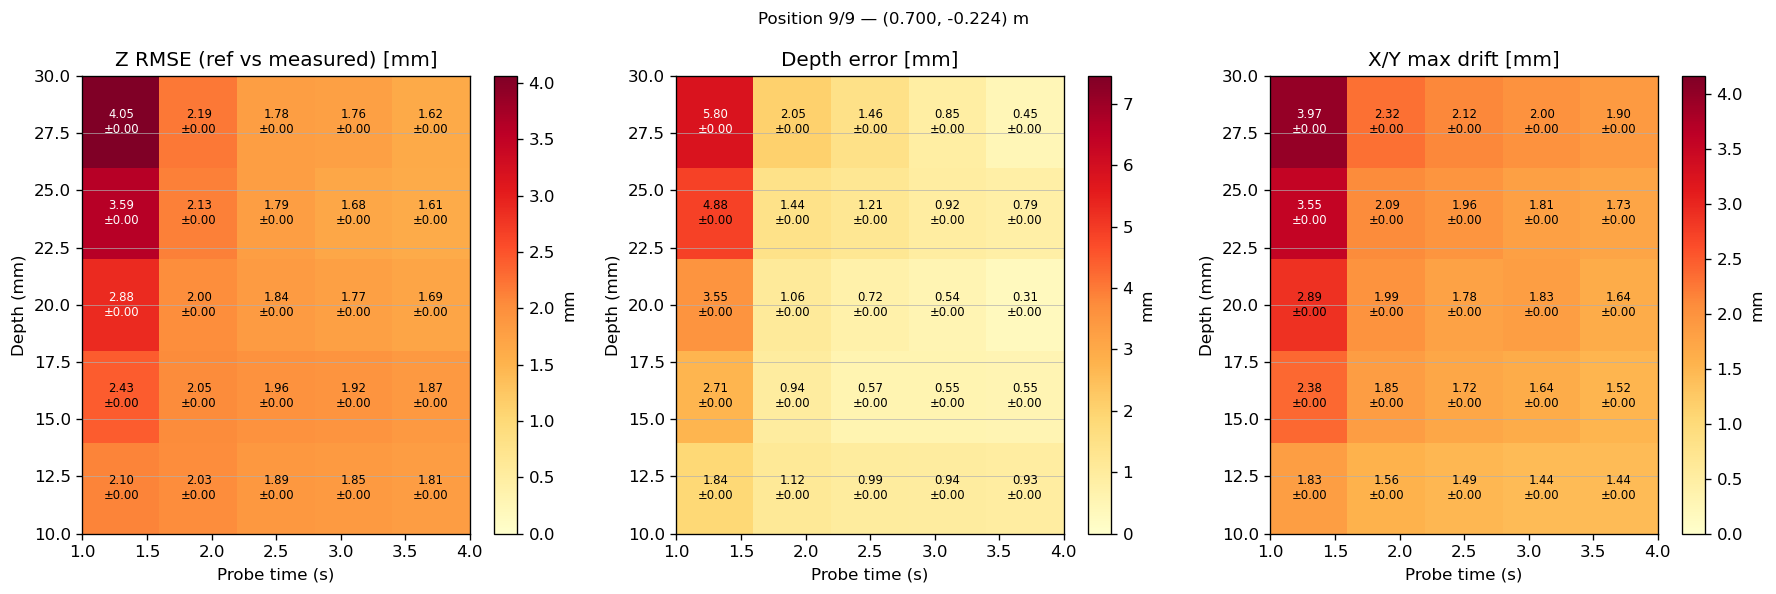

Saved: heatmap_pos08_plunge_benchmark_20260522_124938.png


In [18]:
# ---- Per-position heatmaps ----
if len(positions) > 1:
    # Compute shared colour scale across all positions for fair comparison
    vmax = {}
    for k in METRIC_KEYS:
        all_vals = [per_pos_grids[pi][0][k] for pi in range(len(positions))]
        finite = np.concatenate([v[~np.isnan(v)].ravel() for v in all_vals])
        vmax[k] = float(np.nanmax(finite)) if len(finite) else 1.0

    for pos_idx, (x, y) in enumerate(positions):
        mean_g, std_g = per_pos_grids[pos_idx]
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        draw_heatmap(fig, axes, mean_g, std_g,
                     title=f'Position {pos_idx + 1}/{len(positions)} — ({x:.3f}, {y:.3f}) m',
                     vmax_override=vmax)
        plt.tight_layout()
        out = PLOTS_DIR / f'heatmap_pos{pos_idx:02d}_{RESULT_FILE.stem}.png'
        plt.savefig(out, dpi=150)
        plt.show()
        plt.close(fig)
        print(f'Saved: {out.name}')
else:
    print('Only one position — per-position heatmaps skipped.')

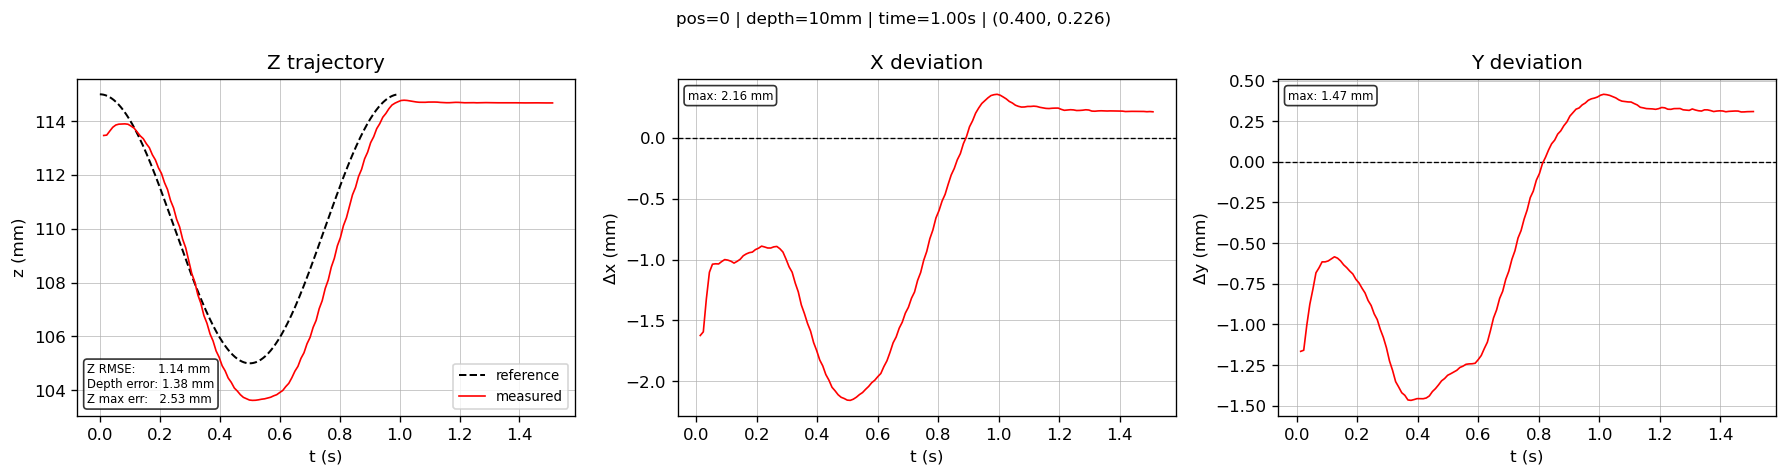

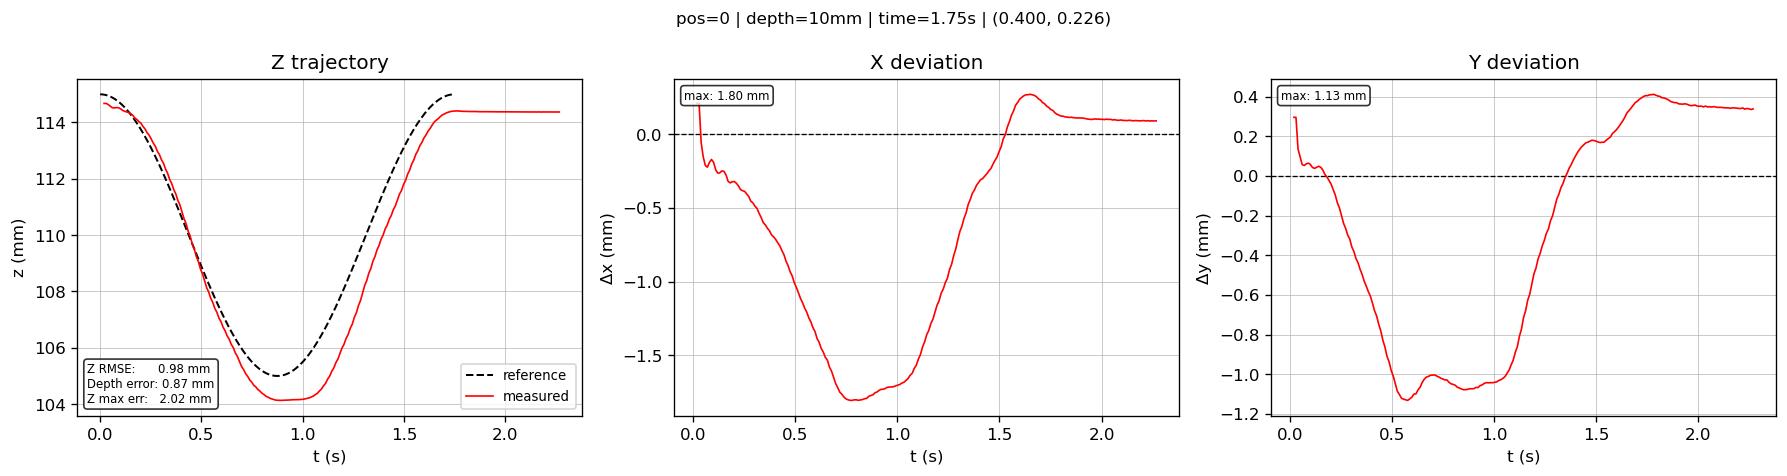

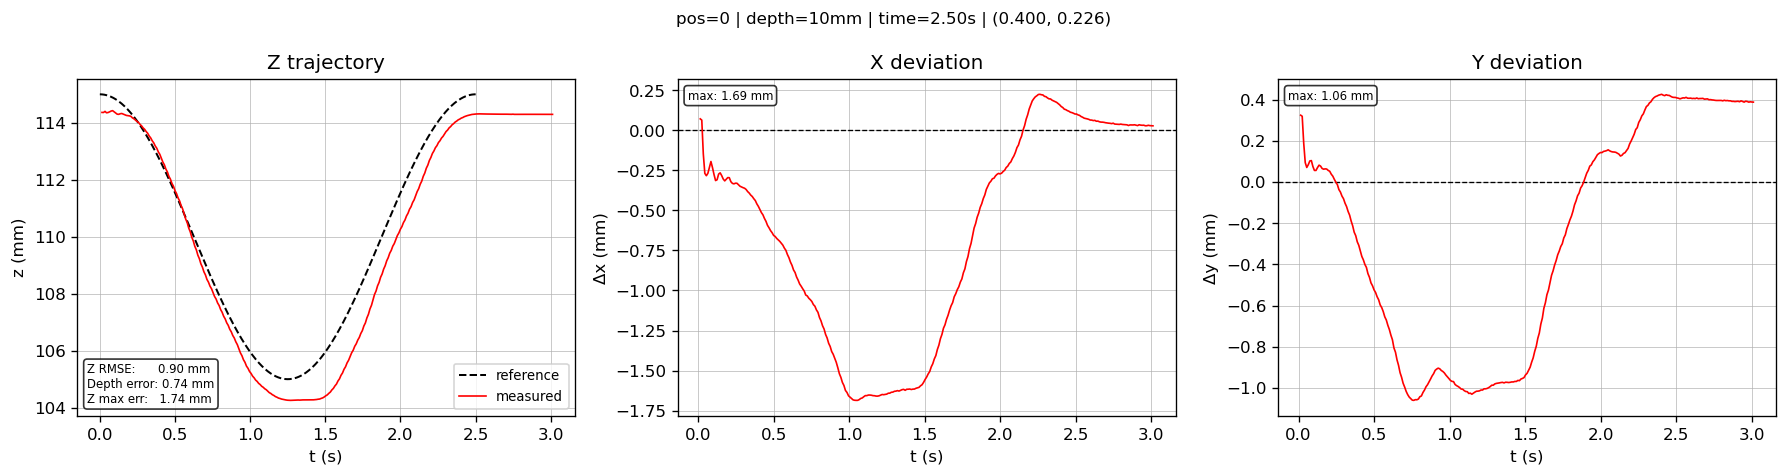

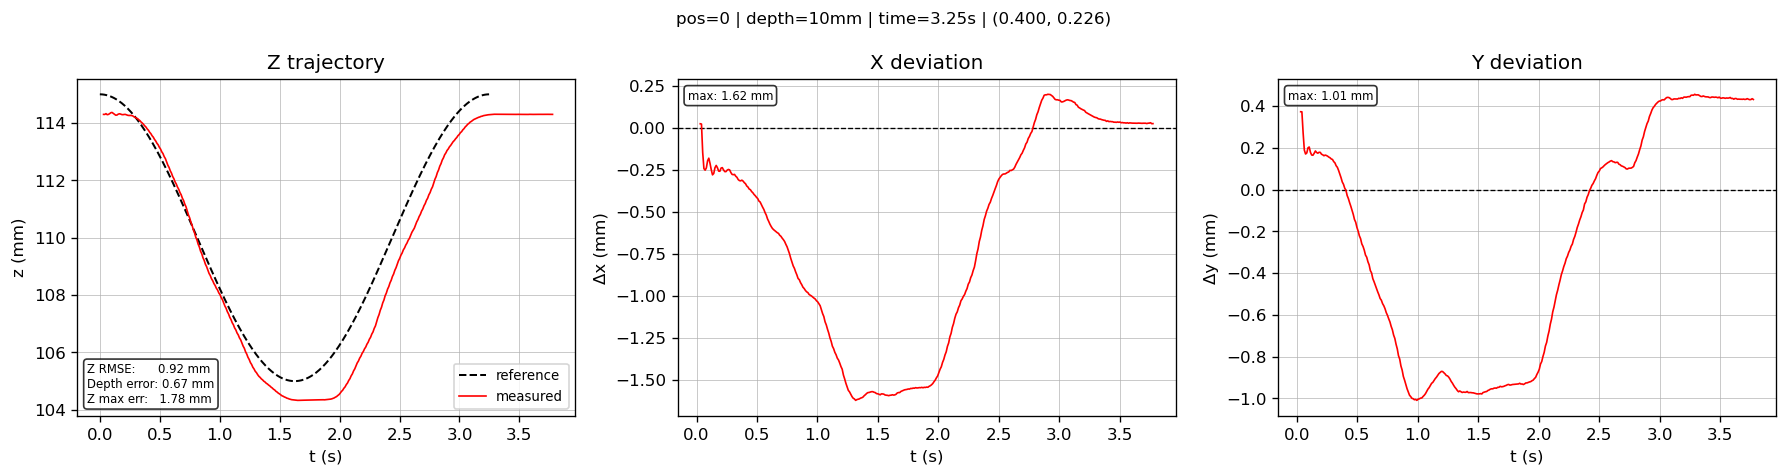

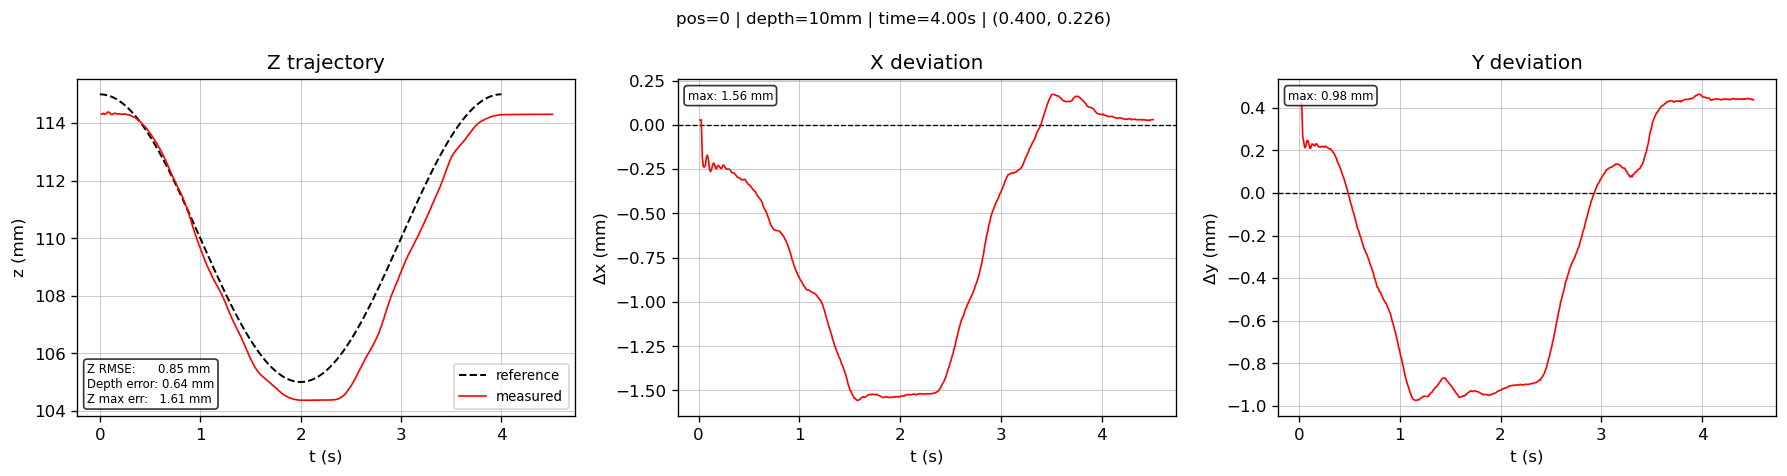

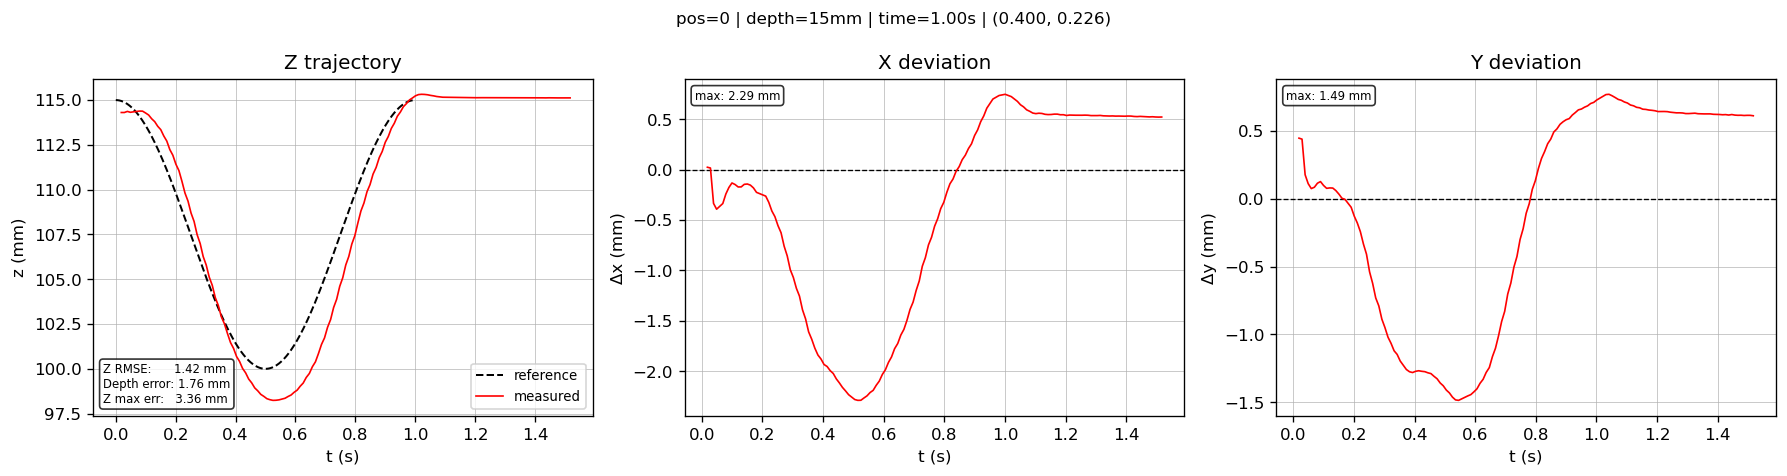

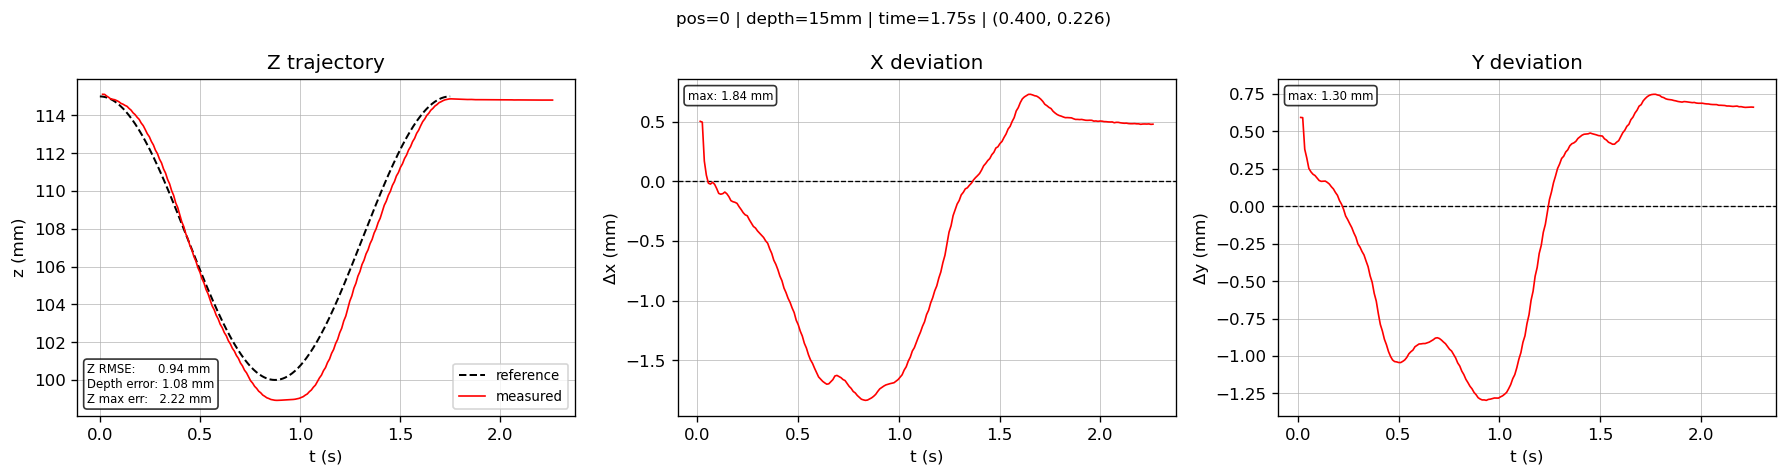

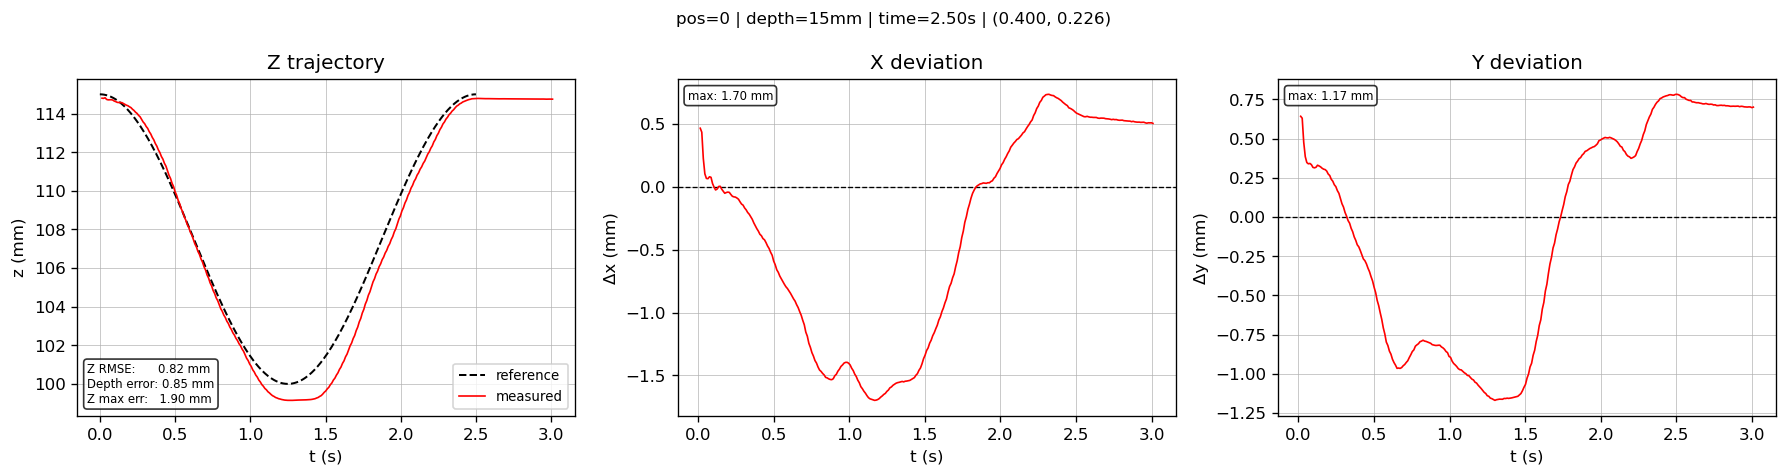

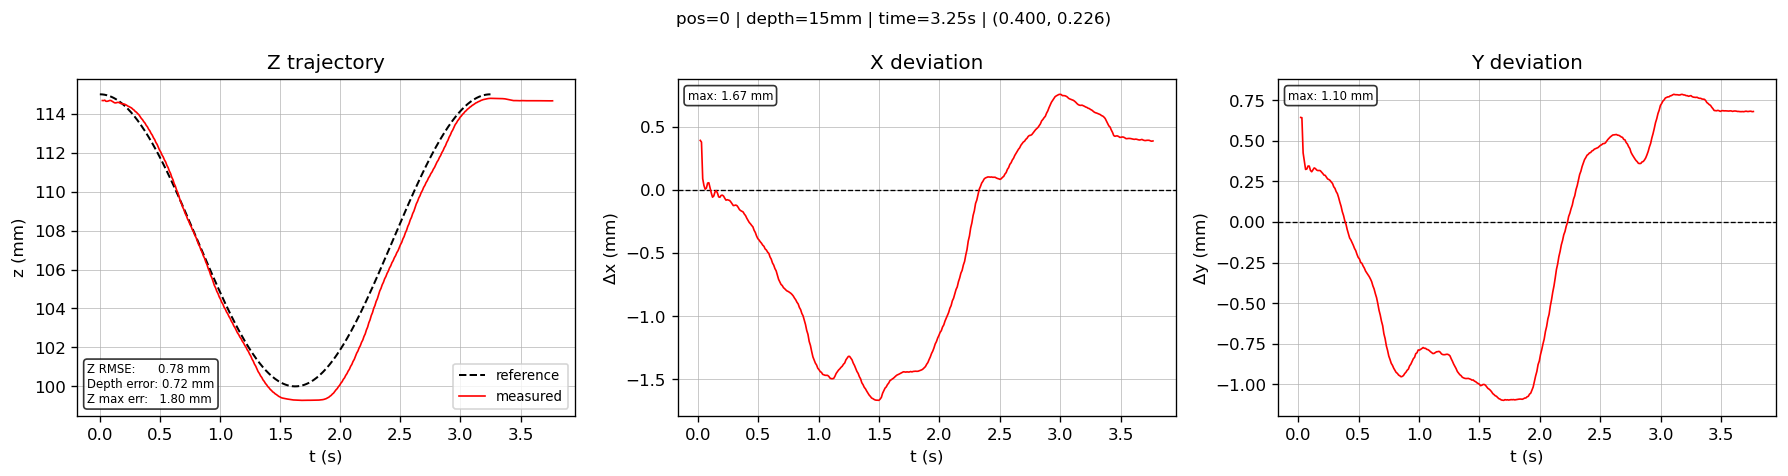

In [19]:
# ---- Per-plunge trajectory plots ----
# Filters: set to None for all, or an int index to restrict
DEPTH_IDX_FILTER = None
TIME_IDX_FILTER  = None
POS_IDX_FILTER   = None
MAX_PLOTS        = 9

subset = [
    r for r in results
    if (DEPTH_IDX_FILTER is None or r['depth_idx'] == DEPTH_IDX_FILTER)
    and (TIME_IDX_FILTER  is None or r['time_idx']  == TIME_IDX_FILTER)
    and (POS_IDX_FILTER   is None or r['pos_idx']   == POS_IDX_FILTER)
][:MAX_PLOTS]

for r in subset:
    ts       = r['ts']
    meas     = r['measured_positions']
    xyz0     = r['target_xyz']
    depth    = r['depth']
    pt       = r['probe_time']
    m        = r['metrics']

    t_ref = np.linspace(0, pt, 500)
    z_ref = reference_z(xyz0[2], depth, pt, t_ref)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(
        f"pos={r['pos_idx']} | depth={depth*1e3:.0f}mm | time={pt:.2f}s | "
        f"({xyz0[0]:.3f}, {xyz0[1]:.3f})",
        fontsize=10
    )

    # Z trajectory + metric annotations
    ax = axes[0]
    ax.plot(t_ref, z_ref * 1e3, 'k--', lw=1.2, label='reference')
    if len(ts) > 0:
        ax.plot(ts, meas[:, 2] * 1e3, 'r-', lw=1.0, label='measured')
    ax.set_xlabel('t (s)'); ax.set_ylabel('z (mm)')
    ax.set_title('Z trajectory'); ax.legend(fontsize=8); ax.grid(lw=0.4)
    # Metric annotations in text box
    ann = (f"Z RMSE:      {m['z_rmse']:.2f} mm\n"
           f"Depth error: {m['depth_error']:.2f} mm\n"
           f"Z max err:   {m['z_max_err']:.2f} mm")
    ax.text(0.02, 0.03, ann, transform=ax.transAxes, fontsize=7,
            va='bottom', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # X deviation
    ax = axes[1]
    ax.axhline(0, color='k', lw=0.8, ls='--', label='target')
    if len(ts) > 0:
        ax.plot(ts, (meas[:, 0] - xyz0[0]) * 1e3, 'r-', lw=1.0)
    ax.set_xlabel('t (s)'); ax.set_ylabel('Δx (mm)')
    ax.set_title('X deviation'); ax.grid(lw=0.4)
    ax.text(0.02, 0.97, f"max: {m['x_max_drift']:.2f} mm",
            transform=ax.transAxes, fontsize=7, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Y deviation
    ax = axes[2]
    ax.axhline(0, color='k', lw=0.8, ls='--', label='target')
    if len(ts) > 0:
        ax.plot(ts, (meas[:, 1] - xyz0[1]) * 1e3, 'r-', lw=1.0)
    ax.set_xlabel('t (s)'); ax.set_ylabel('Δy (mm)')
    ax.set_title('Y deviation'); ax.grid(lw=0.4)
    ax.text(0.02, 0.97, f"max: {m['y_max_drift']:.2f} mm",
            transform=ax.transAxes, fontsize=7, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    fig.tight_layout()
    slug = f"probe_p{r['pos_idx']}_d{r['depth_idx']}_t{r['time_idx']}"
    fig.savefig(PLOTS_DIR / f'{slug}.png', dpi=120)
    plt.show()
    plt.close(fig)